# 02 - Partition Distribution Visualization

Visualize how data is distributed across FL clients after partitioning.
- Per-client sample counts
- Character distribution per client
- Non-IID-ness analysis

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid')

PARTITION_DIR = Path('../data/partitions')

In [2]:
# Load partition summary
summary_path = PARTITION_DIR / 'partition_summary.json'
with open(summary_path) as f:
    summary = json.load(f)

print(f"Partition method: {summary['method']}")
print(f"Number of clients: {len(summary['clients'])}")
print()

for cid, info in summary['clients'].items():
    print(f"  Client {cid}: {info['num_samples']} samples")

Partition method: clustering
Number of clients: 5

  Client 0: 199 samples
  Client 1: 159 samples
  Client 2: 109 samples
  Client 3: 205 samples
  Client 4: 236 samples


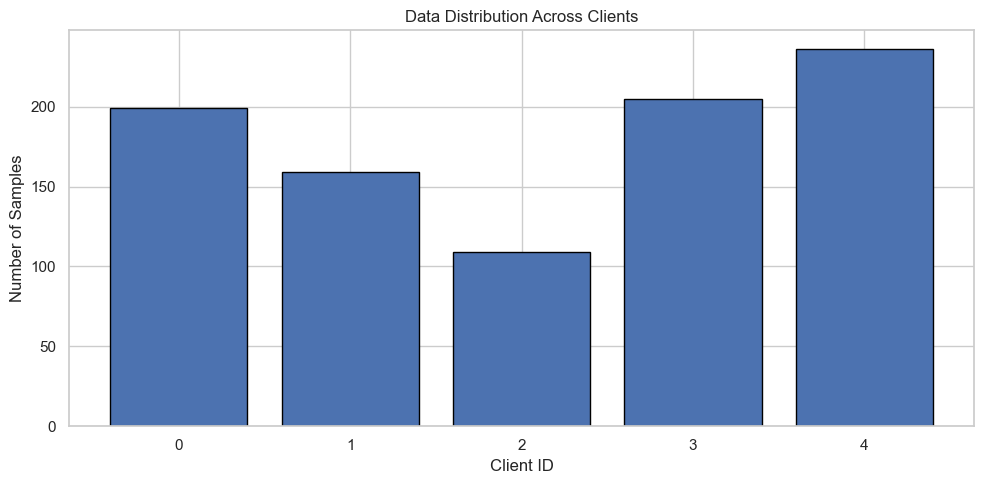

In [3]:
# Bar chart: samples per client
client_ids = list(summary['clients'].keys())
sample_counts = [summary['clients'][c]['num_samples'] for c in client_ids]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(client_ids, sample_counts, edgecolor='black')
ax.set_xlabel('Client ID')
ax.set_ylabel('Number of Samples')
ax.set_title('Data Distribution Across Clients')
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Glyph 3515 (\N{SINHALA LETTER RAYANNA}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from current font.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.11/site-packages/seaborn/utils.py:80: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from current font.
  fig.canvas.dr

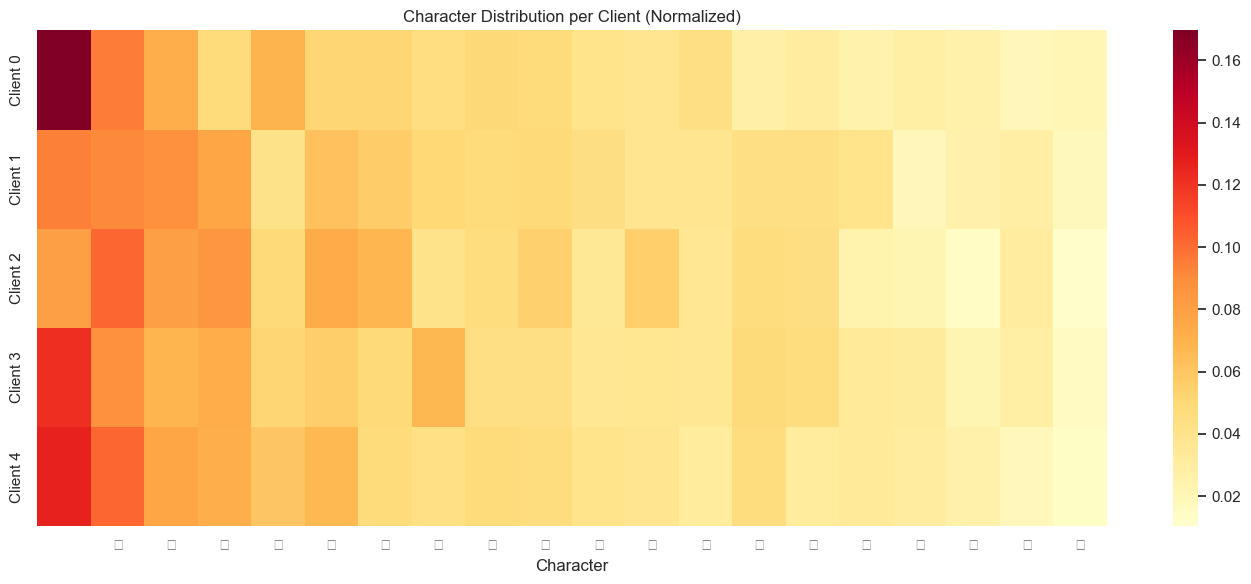

In [4]:
# Character distribution heatmap per client
client_char_counts = {}

for cid in client_ids:
    csv_path = PARTITION_DIR / f'client_{cid}' / 'data.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        chars = Counter()
        for text in df['text'].astype(str):
            chars.update(text)
        client_char_counts[f'Client {cid}'] = chars

# Get top-20 most common chars overall
all_chars = Counter()
for chars in client_char_counts.values():
    all_chars.update(chars)
top_chars = [c for c, _ in all_chars.most_common(20)]

# Build matrix
matrix = []
for client_name in client_char_counts:
    row = [client_char_counts[client_name].get(c, 0) for c in top_chars]
    total = sum(row) or 1
    matrix.append([v / total for v in row])  # normalize

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    matrix,
    xticklabels=top_chars,
    yticklabels=list(client_char_counts.keys()),
    cmap='YlOrRd',
    annot=False,
    ax=ax,
)
ax.set_title('Character Distribution per Client (Normalized)')
ax.set_xlabel('Character')
plt.tight_layout()
plt.show()

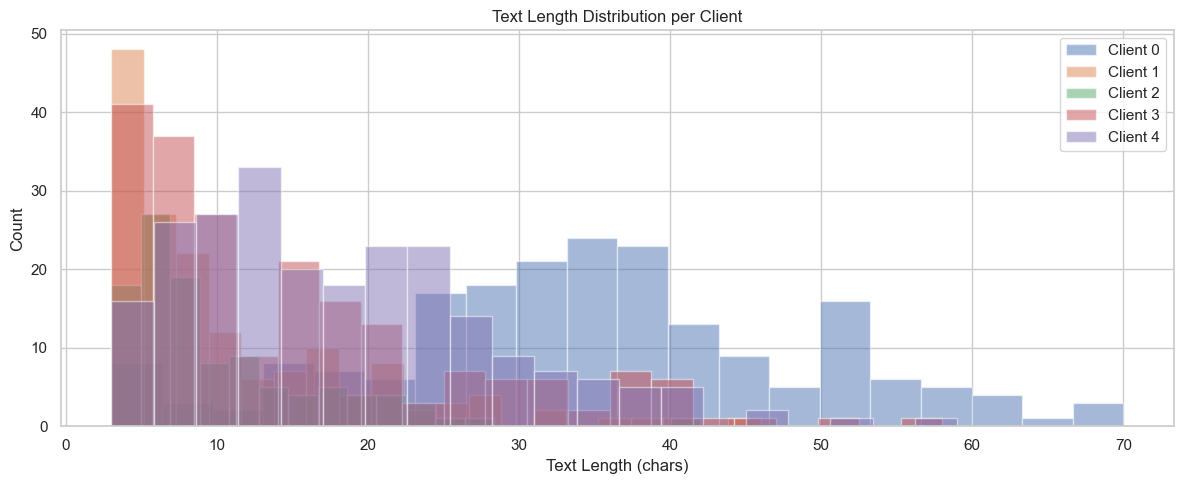

In [5]:
# Text length distribution per client
fig, ax = plt.subplots(figsize=(12, 5))

for cid in client_ids:
    csv_path = PARTITION_DIR / f'client_{cid}' / 'data.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        lengths = df['text'].astype(str).apply(len)
        ax.hist(lengths, bins=20, alpha=0.5, label=f'Client {cid}')

ax.set_xlabel('Text Length (chars)')
ax.set_ylabel('Count')
ax.set_title('Text Length Distribution per Client')
ax.legend()
plt.tight_layout()
plt.show()